In [14]:
%pip install kagglehub[pandas-datasets]
%pip install numpy matplotlib seaborn
%pip install scikit-learn


Note: you may need to restart the kernel to use updated packages.
Note: you may need to restart the kernel to use updated packages.
Note: you may need to restart the kernel to use updated packages.


In [15]:
import kagglehub
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [ ]:
# Download latest version
path = kagglehub.dataset_download("balaka18/email-spam-classification-dataset-csv")

print("Path to dataset files:", path)

c:\Users\Khester Mesa\Documents\projects\email_classification\.venv\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


100%|██████████| 1.66M/1.66M [00:01<00:00, 1.29MB/s]

Extracting files...
Path to dataset files: C:\Users\Khester Mesa\.cache\kagglehub\datasets\balaka18\email-spam-classification-dataset-csv\versions\1


In [ ]:
df = pd.read_csv("C:\\Users\\Khester Mesa\\.cache\\kagglehub\\datasets\\balaka18\\email-spam-classification-dataset-csv\\versions\\1\\emails.csv")

df.head()

,Email No.,the,to,ect,and,for,of,a,you,hou,...,connevey,jay,valued,lay,infrastructure,military,allowing,ff,dry,Prediction
0,Email 1,0,0,1,0,0,0,2,0,0,...,0,0,0,0,0,0,0,0,0,0
1,Email 2,8,13,24,6,6,2,102,1,27,...,0,0,0,0,0,0,0,1,0,0
2,Email 3,0,0,1,0,0,0,8,0,0,...,0,0,0,0,0,0,0,0,0,0
3,Email 4,0,5,22,0,5,1,51,2,10,...,0,0,0,0,0,0,0,0,0,0
4,Email 5,7,6,17,1,5,2,57,0,9,...,0,0,0,0,0,0,0,1,0,0


In [10]:
df.columns

Index(['Email No.', 'the', 'to', 'ect', 'and', 'for', 'of', 'a', 'you', 'hou',
       ...
       'connevey', 'jay', 'valued', 'lay', 'infrastructure', 'military',
       'allowing', 'ff', 'dry', 'Prediction'],
      dtype='str', length=3002)

## Data Cleaning

In [11]:
# Remove email column 
df = df.drop(['Email No.'], axis=1)

In [13]:
# check for missisng values
print("Missisng Values:")
df.isnull().sum().sum()

Missisng Values:


np.int64(0)

The data looks good (since the data already clear and I think we are good to proceed)

## Training

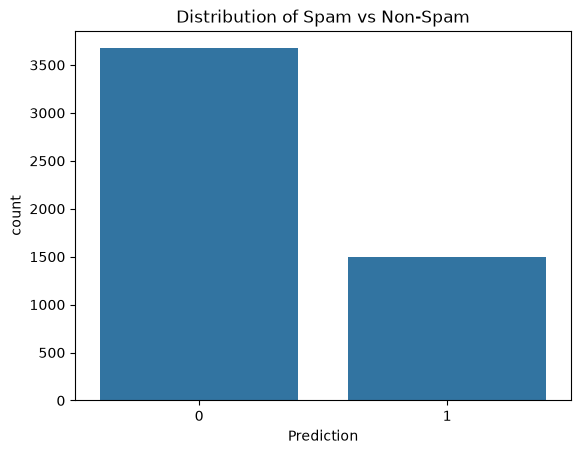

Prediction
0    3672
1    1500
Name: count, dtype: int64


In [16]:
# See the count of Spam (1) vs Non-Spam (0)
sns.countplot(x='Prediction', data=df)
plt.title('Distribution of Spam vs Non-Spam')
plt.show()
print(df['Prediction'].value_counts())

In [17]:
X = df.drop('Prediction', axis=1) # All the word counts
y = df['Prediction']              # Just the labels (0 or 1)

In [18]:
from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test = train_test_split(
    X, y, 
    test_size=0.2, 
    random_state=42, 
    stratify=y  # <--- This is the magic parameter
)

In [19]:
from sklearn.naive_bayes import MultinomialNB
from sklearn.model_selection import cross_val_score, StratifiedKFold
# Initialize the model
model = MultinomialNB()
# Set up the Stratified 5-Fold Cross Validation
skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
# Run the cross validation
# We will check the 'accuracy' for each fold
scores = cross_val_score(model, X, y, cv=skf, scoring='accuracy')
print("Accuracy for each fold:", scores)
print("Average Accuracy:", scores.mean())

Accuracy for each fold: [0.95072464 0.93623188 0.94487427 0.93713733 0.94390716]
Average Accuracy: 0.942575056765621


Check for more metrics

In [20]:
from sklearn.metrics import classification_report

model.fit(X_train, y_train)
y_pred = model.predict(X_test)

print(classification_report(y_test, y_pred))


              precision    recall  f1-score   support

           0       0.98      0.94      0.96       735
           1       0.87      0.94      0.90       300

    accuracy                           0.94      1035
   macro avg       0.92      0.94      0.93      1035
weighted avg       0.94      0.94      0.94      1035



the precision of spam classification is a bit lower than expected. In reality, this might cause a catastrophic consequence if a supposed to be spam is not filtered

## Training of Different ML models for comparison

In [25]:
from sklearn.linear_model import LogisticRegression

# 1. Logistic Regression
print("--- LOGISTIC REGRESSION ---")
# max_iter=1000 ensures it has enough time to converge on a solution
log_model = LogisticRegression(max_iter=1000) 

# Set up the Stratified 5-Fold Cross Validation
skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
# Run the cross validation
# We will check the 'accuracy' for each fold
scores = cross_val_score(log_model, X, y, cv=skf, scoring='accuracy')
print("Accuracy for each fold:", scores)
print("Average Accuracy:", scores.mean())

--- LOGISTIC REGRESSION ---
Accuracy for each fold: [0.97101449 0.98067633 0.9729207  0.97195358 0.96518375]
Average Accuracy: 0.9723497696670684


In [24]:
log_model.fit(X_train, y_train)
y_pred_log = log_model.predict(X_test)
print(classification_report(y_test, y_pred_log))

              precision    recall  f1-score   support

           0       0.99      0.98      0.99       735
           1       0.96      0.98      0.97       300

    accuracy                           0.98      1035
   macro avg       0.98      0.98      0.98      1035
weighted avg       0.98      0.98      0.98      1035



In [26]:
from sklearn.ensemble import RandomForestClassifier

# 2. Random Forest
print("--- RANDOM FOREST ---")
# n_estimators=100 means it will build 100 decision trees
rf_model = RandomForestClassifier(n_estimators=100, random_state=42)
# Set up the Stratified 5-Fold Cross Validation
skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
# Run the cross validation
# We will check the 'accuracy' for each fold
scores = cross_val_score(rf_model, X, y, cv=skf, scoring='accuracy')
print("Accuracy for each fold:", scores)
print("Average Accuracy:", scores.mean())


--- RANDOM FOREST ---
Accuracy for each fold: [0.97391304 0.97874396 0.96808511 0.97195358 0.97195358]
Average Accuracy: 0.972929853577402


In [27]:
rf_model.fit(X_train, y_train)
y_pred_rf = rf_model.predict(X_test)
print(classification_report(y_test, y_pred_rf))

              precision    recall  f1-score   support

           0       0.98      0.97      0.97       735
           1       0.93      0.94      0.94       300

    accuracy                           0.96      1035
   macro avg       0.96      0.96      0.96      1035
weighted avg       0.96      0.96      0.96      1035



## Summary:

Based on the three models, the logistic Regression is clearly the winner given its performance in different metrics. Its performance is almost perfect having a score of 95% above on each metric. 

> The Logistic Regression Model is chosen to be deployed

In [30]:
import joblib
import os
os.makedirs('pkl_files', exist_ok=True)
# 1. Save the Logistic Regression model
joblib.dump(log_model, 'pkl_files/spam_model.pkl')
# 2. Save the list of 3,000 words (the feature columns)
# We drop 'Email No.' and 'Prediction' so we only have the word columns
feature_names = X.columns.tolist()
joblib.dump(feature_names, 'pkl_files/feature_names.pkl')

['pkl_files/feature_names.pkl']